<a href="https://colab.research.google.com/github/sheCodesAI/data-analysis-projects/blob/main/LondonHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv(r"/content/5. London Housing Data.csv", encoding='cp1252')

In [ ]:
data

,date,area,average_price,code,houses_sold,no_of_crimes
0,1/1/1995,city of london,91449,E09000001,17.0,NaN
1,2/1/1995,city of london,82203,E09000001,7.0,NaN
2,3/1/1995,city of london,79121,E09000001,14.0,NaN
3,4/1/1995,city of london,77101,E09000001,7.0,NaN
4,5/1/1995,city of london,84409,E09000001,10.0,NaN
...,...,...,...,...,...,...
13544,9/1/2019,england,249942,E92000001,64605.0,NaN
13545,10/1/2019,england,249376,E92000001,68677.0,NaN
13546,11/1/2019,england,248515,E92000001,67814.0,NaN
13547,12/1/2019,england,250410,E92000001,NaN,NaN


In [ ]:
data.count()

,0
date,13549
area,13549
average_price,13549
code,13549
houses_sold,13549
no_of_crimes,13549


In [ ]:
data.isnull().sum()

,0
date,0
area,0
average_price,0
code,0
houses_sold,94
no_of_crimes,6110


In [ ]:
import seaborn as sns
# to see in heatmap and see visualization

import matplotlib.pyplot as plt

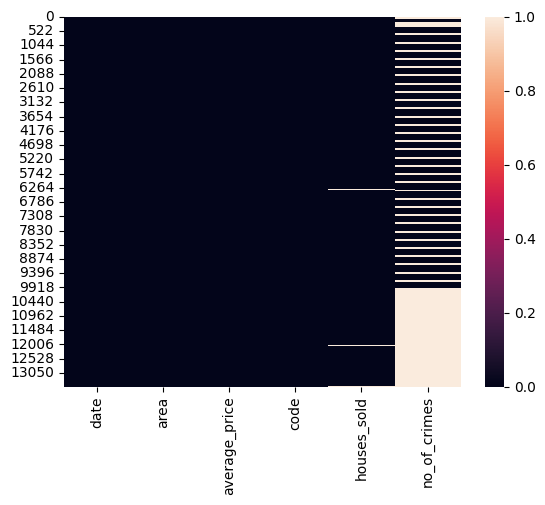

In [ ]:
sns.heatmap(data.isnull())
plt.show()

# **Questions**

## **1. Convert the datatype of 'Date' column to date-time format**

In [ ]:
data.dtypes

,0
date,object
area,object
average_price,int64
code,object
houses_sold,float64
no_of_crimes,float64


In [ ]:
data.date = pd.to_datetime(data.date)

## **2.1 Add new col 'year' in df, which contains year only && month at 2nd col**


In [ ]:
data['year'] = data.date.dt.year

/tmp/ipykernel_9239/2698096357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['year'] = data.date.dt.year


In [ ]:
data['month'] = data['date'].dt.month

# reorder columns
cols = list(data.columns)
cols.insert(1, cols.pop(cols.index('month')))
data = data[cols]

In [ ]:
data

,date,area,average_price,code,houses_sold,no_of_crimes
0,1995-01-01,city of london,91449,E09000001,17.0,NaN
1,1995-02-01,city of london,82203,E09000001,7.0,NaN
2,1995-03-01,city of london,79121,E09000001,14.0,NaN
3,1995-04-01,city of london,77101,E09000001,7.0,NaN
4,1995-05-01,city of london,84409,E09000001,10.0,NaN
...,...,...,...,...,...,...
13544,2019-09-01,england,249942,E92000001,64605.0,NaN
13545,2019-10-01,england,249376,E92000001,68677.0,NaN
13546,2019-11-01,england,248515,E92000001,67814.0,NaN
13547,2019-12-01,england,250410,E92000001,NaN,NaN


## **2.2 Remove the cols 'year' and 'month' from df**

In [ ]:
data.drop(['month', 'year'] , axis = 1, inplace = True)

/tmp/ipykernel_9239/344869080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(['month', 'year'] , axis = 1, inplace = True)


In [ ]:
data.head(1)

,date,area,average_price,code,houses_sold,no_of_crimes
0,1995-01-01,city of london,91449,E09000001,17.0,NaN


## **2.3 Show all the records where 'no. of crimes' is 0, & how many such records are there?**

In [ ]:
data[data.no_of_crimes == 0].head(2)

,date,area,average_price,code,houses_sold,no_of_crimes
72,2001-01-01,city of london,284262,E09000001,24.0,0.0
73,2001-02-01,city of london,198137,E09000001,37.0,0.0


In [ ]:
len(data[data.no_of_crimes == 0])

104

## **2.4 what is the max and min 'avergage_price' per year in england?**

In [ ]:
df1 = data[data.area == 'england']

In [ ]:
data.head()

,date,area,average_price,code,houses_sold,no_of_crimes
0,1995-01-01,england,91449,E09000001,17.0,NaN
1,1995-02-01,england,82203,E09000001,7.0,NaN
2,1995-03-01,england,79121,E09000001,14.0,NaN
3,1995-04-01,england,77101,E09000001,7.0,NaN
4,1995-05-01,england,84409,E09000001,10.0,NaN


In [ ]:
df1['year'] = df1.date.dt.year
df1.groupby('year')['average_price'].agg(['max', 'min']).head()

,max,min
year,,
1995,200722,41688
1996,223197,40722
1997,265112,42353
1998,277600,43510
1999,354241,43969


## **2.5 what is the max and min no of crimes recorded per area?**

In [ ]:
data.groupby('area').no_of_crimes.max()

,no_of_crimes
area,
england,7461.0


## **2.6 max and min no of crimes recorded per area?**

In [ ]:
data = pd.read_csv(r"/content/5. London Housing Data.csv", encoding='cp1252')

In [ ]:
data.groupby('area').no_of_crimes.agg(['min' , 'max']).sort_values(by='min', ascending=True).tail(15)

,min,max
area,,
southwark,2267.0,3821.0
lambeth,2381.0,4701.0
westminster,3504.0,7461.0
east midlands,NaN,NaN
east of england,NaN,NaN
england,NaN,NaN
inner london,NaN,NaN
london,NaN,NaN
north east,NaN,NaN


**now all the values which r NaN goes down** , we have to clean data

## **2.7 show total count of records of each area, which avg price is < 100000**

In [ ]:
data[data.average_price < 100000].area.value_counts()

,count
area,
north east,112
north west,111
yorks and the humber,110
east midlands,96
west midlands,94
england,87
barking and dagenham,85
south west,78
east of england,76
